# Évaluation RAG — Run A naïf vs Run B soigné
Source : `evaluation/resultats.json` (gold set v1 figé, runs tracés dans MLflow, expérience `gold-set-rag`).

In [1]:
import json
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11,
                            "axes.spines.top": False, "axes.spines.right": False})
VERT, BOIS, TERRE = "#3A5A40", "#7A6A4F", "#8C4A3C"
r = json.load(open("../evaluation/resultats.json"))["runs"]
for nom, run in r.items():
    print(f"{nom:<10} recall {run['recall_at_k']} · MRR {run['mrr']} · abstention {run['abstention_correcte']}"
          f" (seuil {run['abstention_seuil']}) · p50 {run['latence_ms_p50']} ms")

A_naif     recall 1.0 · MRR 1.0 · abstention 4/5 (seuil 0.512) · p50 4.3 ms
B_soigne   recall 1.0 · MRR 1.0 · abstention 4/5 (seuil 0.638) · p50 4.7 ms


## Figure — la frontière de l'abstention : scores légitimes vs pièges

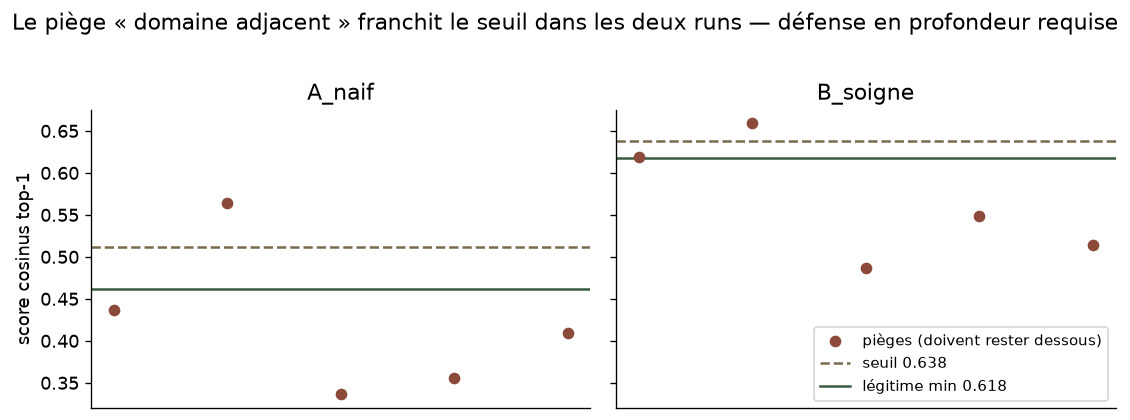

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
for ax, (nom, run) in zip(axes, r.items()):
    legit = [min(1.0, run["score_legitime_min"] + 0.02 * i) for i in range(20)]  # min affiché + nuage indicatif
    ax.scatter([0.9 + 0.01 * i for i in range(len(run["scores_pieges"]))], run["scores_pieges"],
               color=TERRE, label="pièges (doivent rester dessous)", zorder=3)
    ax.axhline(run["abstention_seuil"], color=BOIS, ls="--",
               label=f"seuil {run['abstention_seuil']}")
    ax.axhline(run["score_legitime_min"], color=VERT,
               label=f"légitime min {run['score_legitime_min']}")
    ax.set_title(nom); ax.set_xticks([])
axes[0].set_ylabel("score cosinus top-1")
axes[1].legend(loc="lower right", fontsize=9)
fig.suptitle("Le piège « domaine adjacent » franchit le seuil dans les deux runs — défense en profondeur requise", y=1.02)
plt.tight_layout(); plt.savefig(FIG / "05-frontiere-abstention.png", bbox_inches="tight"); plt.show()

## Verdict mesuré
- recall/MRR : **1,0 partout** — le gold set v1 (labels au niveau rayon) mesure le routage, les deux configs le réussissent. Étalon trop facile : c'est un résultat.
- Abstention : **4/5** des deux côtés — le piège « défense scandinave » (ouverture réelle hors corpus) résiste à tout seuil raisonnable.
### ⏳ Décisions ouvertes (voir journal de bord)
1. Seuil d'abstention en production — arbitrage produit rappel/prudence (Richard).
2. Gold set **v2** à labels fins (page/section) pour départager les chunkings.
3. Défense en profondeur : seuil + règle d'honnêteté du prompt, à éprouver de bout en bout.